# ORIE 4820 Capstone Project
## Optimizing Healthcare Insurance Outreach Across New York State Counties

**Objective:** Maximize the number of newly insured low-income individuals (age 21–64, income ≤ 200% FPL) by optimally allocating outreach resources across New York State counties, with an equity constraint ensuring underserved counties receive attention.

**Data Source:** U.S. Census Bureau Small Area Health Insurance Estimates (SAHIE), 2023

In [10]:
# !pip install ortools

In [11]:
import pandas as pd
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# read excel file
df = pd.read_excel("NewYork_SAHIE_PivotTable.xlsx", sheet_name="NewYork_SAHIE_Combined")
# df = pd.read_csv("NewYork_SAHIE_PivotTable.csv") # uncomment if using a csv (I'm using excel)

In [ ]:
# Filter to county-level rows, low-income adults (<=200% FPL), all races/sexes, year 2023
df = df[
    (df["agecat"] == 5) &       # age 21–64
    (df["racecat"] == 0) &      # all races
    (df["sexcat"] == 0) &       # both sexes
    (df["iprcat"] == 1) &       # low-income (<=200% FPL)
    (df["year"] == 2023) &
    (df["countyfips"] != 0)     # exclude statewide aggregate row
]

# Keep relevant columns
df = df[["countyfips", "county_name", "NUI", "PCTUI", "NIPR"]].copy()

# PARAMETERS 
# x_i represents outreach program funding allocated to county i (in $1,000s).
# This includes navigator programs, community health worker hours, and ACA/
# Medicaid enrollment events — modeled as a single fungible resource.

B        = 1000   # total outreach budget ($1,000s)
K        = 10     # max counties to target
M        = 100    # max funding per county ($1,000s)
k        = 10     # effectiveness scaling: newly insured per $1k per unit of PCTUI
x_min    = 20     # minimum funding if a county is selected ($1,000s) — ensures viable program size
cap_rate = 0.20   # max share of uninsured enrollable per program cycle (operational capacity limit)
min_underserved = 3  # equity requirement: min underserved counties in solution

# Normalize PCTUI (% --> fraction)
df["PCTUI"] = df["PCTUI"] / 100.0

# alpha_i: estimated newly insured per $1k of outreach spending
# Higher uninsured rate --> larger pool of reachable uninsured --> greater marginal return
df["alpha"] = k * df["PCTUI"]

# Enrollment capacity: newly insured <= cap_rate x NUI_i  -->  x_i <= cap_rate x NUI_i / alpha_i
df["capacity"] = cap_rate * df["NUI"] / df["alpha"]

# Underserved flag: county uninsured rate above statewide county median
median_pctui = df["PCTUI"].median()
df["underserved"] = (df["PCTUI"] > median_pctui).astype(int)

print(f"Median county uninsured rate: {median_pctui:.3f}")
print(f"Underserved counties (PCTUI > median): {df['underserved'].sum()} of {len(df)}")

counties = df.index.tolist()

Median county uninsured rate: 0.100
Underserved counties (PCTUI > median): 31 of 62


## LP Model Formulation

**Sets:** $\mathcal{I}$ — New York State counties

**Decision variables:**
- $x_i \geq 0$                := outreach program funding allocated to county $i$ (1,000s)
- $y_i \in \{0,1\}$           :=  1 if county $i$ is selected for intervention

**Parameters:** $B$ = budget (1,000s), $K$ = max counties, $M$ = max funding per county, $x_{\min}$ = minimum funding if selected, $\alpha_i = k \cdot \text{PCTUI}_i$ = newly insured per 1k spent, $\text{NUI}_i$ = uninsured population, $c_i = \rho \cdot \text{NUI}_i\,/\,\alpha_i$ = enrollment capacity ($\rho$ = max enrollable fraction per cycle), $u_i \in \{0,1\}$ = underserved indicator, $R$ = min underserved counties required

$$\max \sum_{i \in \mathcal{I}} \alpha_i x_i$$

$$\text{s.t.} \quad \sum_{i \in \mathcal{I}} x_i \leq B \tag{budget}$$

$$x_{\min}\, y_i \leq x_i \leq M\, y_i \qquad \forall\, i \in \mathcal{I} \tag{linking + min investment}$$

$$\sum_{i \in \mathcal{I}} y_i \leq K \tag{county limit}$$

$$x_i \leq \text{NUI}_i \qquad \forall\, i \in \mathcal{I} \tag{uninsured cap}$$

$$x_i \leq c_i \qquad \forall\, i \in \mathcal{I} \tag{enrollment capacity}$$

$$\sum_{i \in \mathcal{I}} u_i\, y_i \geq R \tag{underserved equity}$$

$$y_i \in \{0,1\} \qquad \forall\, i \in \mathcal{I}$$

In [14]:
df.head()

,countyfips,county_name,NUI,PCTUI,NIPR,alpha,capacity,underserved
13801,1,Albany County ...,3912,0.100,38990,1.00,782.400000,1
13897,3,Allegany County ...,642,0.093,6896,0.93,138.064516,0
13993,5,Bronx County ...,37428,0.110,340919,1.10,6805.090909,1
14089,7,Broome County ...,3182,0.099,32117,0.99,642.828283,0
14185,9,Cattaraugus County ...,1121,0.088,12775,0.88,254.772727,0


In [ ]:
# CREATE SOLVER 
solver = pywraplp.Solver.CreateSolver("gurobi")
if solver is None:
    raise RuntimeError("Could not create solver. Ensure OR-Tools is installed.")

# DECISION VARIABLES
x = {}
y = {}

for i in counties:
    x[i] = solver.NumVar(0, M, f"x_{i}")     # outreach funding ($1,000s) for county i
    y[i] = solver.BoolVar(f"y_{i}")          # 1 if county i is selected

# OBJECTIVE: maximize total estimated newly insured individuals
solver.Maximize(
    solver.Sum(df.loc[i, "alpha"] * x[i] for i in counties)
)

# (1) Budget
solver.Add(solver.Sum(x[i] for i in counties) <= B)

# (2) Linking: funding only flows to selected counties (upper bound)
for i in counties:
    solver.Add(x[i] <= M * y[i])

# (3) Minimum investment: selected counties must receive at least x_min ($1,000s)
for i in counties:
    solver.Add(x[i] >= x_min * y[i])

# (4) County limit
solver.Add(solver.Sum(y[i] for i in counties) <= K)

# (5) Allocation cannot exceed county's uninsured population
for i in counties:
    solver.Add(x[i] <= df.loc[i, "NUI"])

# (6) Enrollment capacity: newly insured ≤ cap_rate x NUI_i per program cycle
for i in counties:
    solver.Add(x[i] <= df.loc[i, "capacity"])

# (7) Equity: at least min_underserved underserved counties must be targeted
solver.Add(solver.Sum(df.loc[i, "underserved"] * y[i] for i in counties) >= min_underserved)

# SOLVE
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print("Optimal solution found!\n")

    total_newly_insured = 0

    for i in counties:
        if y[i].solution_value() > 0.5:
            alloc = x[i].solution_value()
            newly_insured = df.loc[i, "alpha"] * alloc
            tag = " [underserved]" if df.loc[i, "underserved"] == 1 else ""
            total_newly_insured += newly_insured

            print(f"{df.loc[i, 'county_name'].strip()}{tag}:")
            print(f"  Outreach funding: ${alloc:.1f}k")
            print(f"  Estimated newly insured: {newly_insured:.0f}\n")

    print(f"Total estimated newly insured: {total_newly_insured:.0f}")
else:
    print("No optimal solution found.")

Optimal solution found!

Dutchess County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 126

Nassau County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 135

Orange County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 132

Putnam County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 142

Queens County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 159

Rockland County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 150

Suffolk County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 144

Sullivan County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 121

Ulster County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 159

Westchester County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 152

Total estimated newly insured: 1420


In [16]:
# creating a ressults df to compare old vs new pct uninsured after allocation
results = []

for i in counties:
    alloc = x[i].solution_value()
    alpha = df.loc[i, "alpha"]
    z = alpha * alloc

    NUI_old = df.loc[i, "NUI"]
    NIPR = df.loc[i, "NIPR"]

    NUI_new = max(NUI_old - z, 0)
    pct_new = NUI_new / NIPR

    results.append({
        "county": df.loc[i, "county_name"],
        "old_pct": df.loc[i, "PCTUI"],
        "new_pct": pct_new
    })

results_df = pd.DataFrame(results)

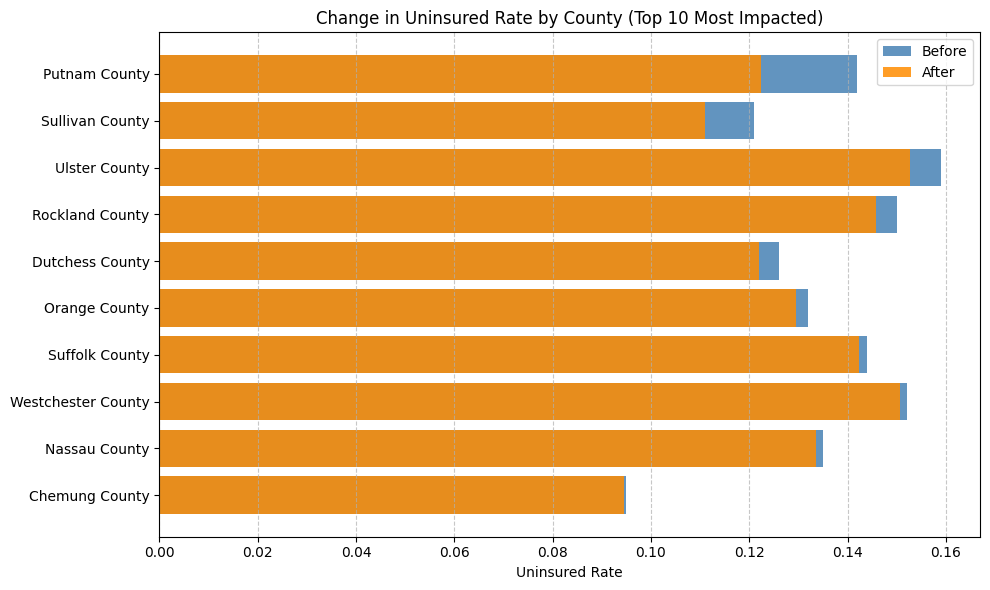

In [17]:
# Clean county names
plot_df = results_df.copy()
plot_df["county"] = plot_df["county"].str.strip()

# Remove blank rows
plot_df = plot_df[plot_df["county"] != ""]

# Compute uninsured rate reduction
plot_df["reduction"] = plot_df["old_pct"] - plot_df["new_pct"]

# Top 10 most impacted counties
plot_df = plot_df.sort_values(by="reduction", ascending=False).head(10)

# Reverse for horizontal bar chart display order
plot_df = plot_df[::-1]

positions = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))

plt.barh(positions, plot_df["old_pct"], label="Before", color="steelblue", alpha=0.85)
plt.barh(positions, plot_df["new_pct"], label="After", color="darkorange", alpha=0.85)

plt.yticks(positions, plot_df["county"])
plt.xlabel("Uninsured Rate")
plt.title("Change in Uninsured Rate by County (Top 10 Most Impacted)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
# export results to csv
results_df.to_csv('results.csv', index=False)
print('results.csv exported successfully!')

results.csv exported successfully!


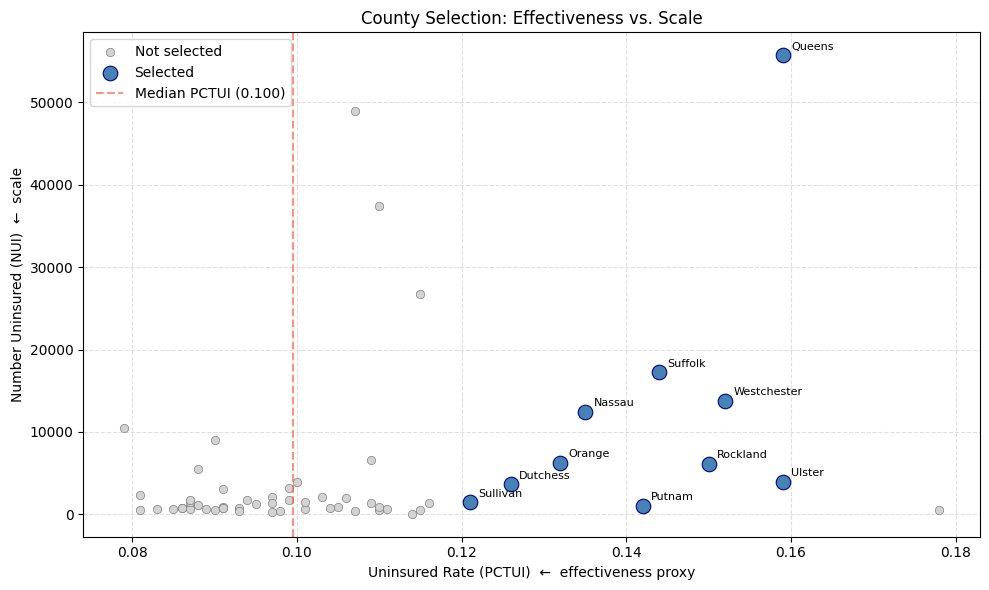

In [19]:
# Decision insight: why were these counties selected?
# Plot all counties by effectiveness (PCTUI) vs. scale (NUI), highlighting selected ones.

selected     = [i for i in counties if y[i].solution_value() > 0.5]
not_selected = [i for i in counties if y[i].solution_value() <= 0.5]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    [df.loc[i, "PCTUI"] for i in not_selected],
    [df.loc[i, "NUI"] for i in not_selected],
    color="lightgray", edgecolors="gray", linewidths=0.5,
    label="Not selected", zorder=2
)
ax.scatter(
    [df.loc[i, "PCTUI"] for i in selected],
    [df.loc[i, "NUI"] for i in selected],
    color="steelblue", s=110, edgecolors="navy", linewidths=0.8,
    label="Selected", zorder=3
)

for i in selected:
    name = df.loc[i, "county_name"].strip().replace(" County", "")
    ax.annotate(name, (df.loc[i, "PCTUI"], df.loc[i, "NUI"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axvline(median_pctui, color="tomato", linestyle="--", alpha=0.7,
           label=f"Median PCTUI ({median_pctui:.3f})")

ax.set_xlabel("Uninsured Rate (PCTUI)  ←  effectiveness proxy")
ax.set_ylabel("Number Uninsured (NUI)  ←  scale")
ax.set_title("County Selection: Effectiveness vs. Scale")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Decision Insight

The model selects counties that rank highest in $\alpha_i = k \cdot \text{PCTUI}_i$. All selected counties sit **to the right of the median PCTUI line**. Since the budget and per-county cap ($M$) cause most counties to hit their allocation ceiling, the selection problem reduces largely to a ranking by uninsured rate.

The key tradeoff the scatter plot reveals: the model does **not** simply pick the largest counties. Large urban counties (e.g., Bronx, Kings) with moderate uninsured rates are passed over in favor of smaller counties with higher rates, because each dollar of outreach yields more enrollments where the uninsured pool is proportionally larger. The enrollment capacity constraint ($x_i \leq c_i$) enforces a realistic ceiling on this, preventing the model from over-allocating to tiny counties that lack the infrastructure to absorb unlimited outreach dollars in one program cycle.